# Thompson Sampling

## Importing the libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

## Importing the dataset

In [2]:
dataset = pd.read_csv('Ads_CTR_Optimisation.csv')

## Implementing Thompson Sampling

In [3]:
import random
N = 10000
d = 10
ads_selected = []
numer_of_rewards_1 = [0] * d
numer_of_rewards_0 = [0] * d
total_reward = 0
for n in range(0, N):
    ad = 0
    max_upper_bound = 0
    for i in range(0, d):
        random_beta = random.betavariate(numer_of_rewards_1[i] + 1, numer_of_rewards_0[i] + 1)
        if random_beta > max_upper_bound:
            max_upper_bound = random_beta
            ad = i
    ads_selected.append(ad)
    reward = dataset.values[n, ad]
    if reward == 1:
        numer_of_rewards_1[ad] += 1
    else:
        numer_of_rewards_0[ad] += 1
    total_reward += reward


## Visualising the results - Histogram

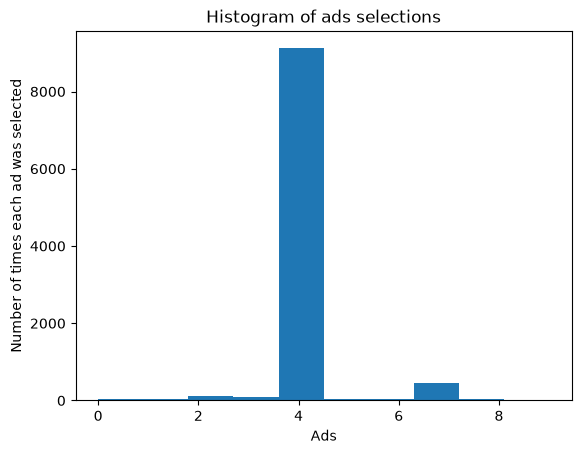

In [4]:
plt.hist(ads_selected)
plt.title('Histogram of ads selections')
plt.xlabel('Ads')
plt.ylabel('Number of times each ad was selected')
plt.show()